In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import build_coverage_report_treenet_utc as ct
import build_normalized_dataset_treenet_utc as bt

# Data coverage analysis

In [2]:
import pandas as pd
from build_normalized_dataset_treenet_utc import discover_series_ids, series_by_site

metadata_pickle = "/storage/lukovic/Data/FORWARDS/treenet/server_data/metadata_all.pkl"
thermo_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/thermometer_l1"
hygro_dir  = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
d2_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2"
lm_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm"

md = pd.read_pickle(metadata_pickle)

# From directories (filename patterns)
thermo_ids_all = discover_series_ids(thermo_dir, 'thermometer_l1')
hygro_ids_all  = discover_series_ids(hygro_dir,  'hygrometer_l1')
d2_ids_all     = discover_series_ids(d2_dir,     'dendrometer_l2')
lm_ids_all     = discover_series_ids(lm_dir,     'dendrometer_lm')

thermo_by_site = series_by_site(md, thermo_ids_all)
hygro_by_site  = series_by_site(md, hygro_ids_all)
d2_by_site     = series_by_site(md, d2_ids_all)
lm_by_site     = series_by_site(md, lm_ids_all)

print("Site 3 (dirs): T =", thermo_by_site.get(3), " RH =", hygro_by_site.get(3),
      " L2 =", d2_by_site.get(3), " LM =", lm_by_site.get(3))

# From metadata 'variable_name' tokens (what the function uses now)
var = md[md['site_id']==3]['variable_name'].astype(str).str.lower()
print("Site 3 variable_name examples:", var.unique()[:10])


Site 3 (dirs): T = [9, 10]  RH = [7, 8]  L2 = [18, 19, 20, 21, 22, 23, 24]  LM = [18, 19, 20, 21, 22, 23, 24]
Site 3 variable_name examples: ['precipitation' 'net solar radiation' 'relative humidity'
 'air temperature' 'wind speed' 'soil temperature' 'soil water potential'
 'tree stem radius change']


In [3]:

from build_normalized_dataset_treenet_utc import read_lm_hourly_frame_utc
lm_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm"
df_lm_hr = read_lm_hourly_frame_utc(18, lm_dir, "Europe/Zurich")
print('LM hourly total rows:', len(df_lm_hr), 'UTC range:', df_lm_hr.index.min(), '→', df_lm_hr.index.max())
print('Rows in 2019:', len(df_lm_hr['2019-01-01':'2019-12-31']))


LM hourly total rows: 87815 UTC range: 2014-12-31 00:00:00+00:00 → 2025-01-05 22:00:00+00:00
Rows in 2019: 8760


In [1]:
from build_normalized_dataset_treenet_utc import make_multi_year_10m_index_utc, rolling_year_windows
idx = make_multi_year_10m_index_utc([2019])
wins = rolling_year_windows(idx)
print(len(wins), wins[0] if wins else None)
# Expected: 1 (Timestamp('2019-01-01 00:00:00+0000', tz='UTC'),
#                 Timestamp('2020-01-01 00:00:00+0000', tz='UTC'))



1 (Timestamp('2019-01-01 00:00:00+0000', tz='UTC'), Timestamp('2020-01-01 00:00:00+0000', tz='UTC'))


In [2]:

# Inspect diagnostics for site 3
import pandas as pd
diag = pd.read_csv('/home/lukovic/data/treenet/outputs_yearly/diagnostics/diagnostics_preprocessing.csv')

print("Warnings (site 3):")
print(diag[diag['site_id']==3]['warning'].value_counts(dropna=False))

print("\nFirst 40 rows for site 3:")
print(diag[diag['site_id']==3].head(40))


Warnings (site 3):
warning
low_local_coverage_combo                   36
NaN                                        14
lm_hourly_targets_all_nan_after_reindex     2
Name: count, dtype: int64

First 40 rows for site 3:
    site_id  split       debug_type  thermo_ids_count  hygro_ids_count  \
0         3  train  site_inspection               5.0              2.0   
1         3  train  site_inspection               5.0              2.0   
2         3  train  site_inspection               5.0              2.0   
3         3  train  site_inspection               5.0              2.0   
4         3  train  site_inspection               5.0              2.0   
5         3  train  site_inspection               5.0              2.0   
6         3  train  site_inspection               5.0              2.0   
7         3  train              NaN               NaN              NaN   
8         3  train              NaN               NaN              NaN   
9         3  train              NaN       

In [8]:

import pandas as pd
import numpy as np
from build_normalized_dataset_treenet_utc import (
    make_multi_year_10m_index_utc, broadcast_daily_civil_to_utc_grid,
    load_global_daily_civil, read_feather_series_utc, bin_to_10min_utc,
    read_lm_hourly_frame_utc, coverage_fraction
)

# Paths
local_tz = "Europe/Zurich"
thermo_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/thermometer_l1"
hygro_dir  = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
d2_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2"
lm_dir     = "/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm"
meteo_dir  = "/storage/lukovic/Data/FORWARDS/treenet/meteo_data"

# IDs
site_id = 3
t_id, h_id, d_id = 10, 8, 18
years = [2019]

# Master indices & globals
idx_10m = make_multi_year_10m_index_utc(years)
glb_daily = load_global_daily_civil(site_id, meteo_dir)
glb_10m = broadcast_daily_civil_to_utc_grid(glb_daily, idx_10m, tz_local=local_tz)
glb_win = glb_10m['2019-01-01':'2020-01-01']

print("glb_win shape:", glb_win.shape)  # Should be (52560, 7)

# Read locals
s_T_full = read_feather_series_utc(t_id, thermo_dir, local_tz, sensor_hint='thermometer_l1')
s_RH_full= read_feather_series_utc(h_id, hygro_dir,  local_tz, sensor_hint='hygrometer_l1')
s_ST_full= read_feather_series_utc(d_id, d2_dir,     local_tz, sensor_hint='dendrometer_l2')

# Bin deterministically to 10-min UTC, align to year grid
s_T_full = bin_to_10min_utc(s_T_full, method='resample', how='median').reindex(idx_10m)
s_RH_full= bin_to_10min_utc(s_RH_full, method='resample', how='median').reindex(idx_10m)
s_ST_full= bin_to_10min_utc(s_ST_full, method='resample', how='median').reindex(idx_10m)

sT_w  = s_T_full['2019-01-01':'2020-01-01']
sRH_w = s_RH_full['2019-01-01':'2020-01-01']
sST_w = s_ST_full['2019-01-01':'2020-01-01']

print("Coverage T/RH/ST:",
      coverage_fraction(sT_w),
      coverage_fraction(sRH_w),
      coverage_fraction(sST_w))

# LM hourly targets (same dendro id)
df_lm_hr = read_lm_hourly_frame_utc(d_id, lm_dir, local_tz)
dfh = df_lm_hr['2019-01-01':'2020-01-01']
print("LM hourly 2019 rows:", len(dfh), "NaN ratio:", dfh.isna().mean().to_dict())


glb_win shape: (52560, 7)
Coverage T/RH/ST: 0.6185882800608828 0.6185882800608828 0.5491628614916286
LM hourly 2019 rows: 8784 NaN ratio: {'stem': 1.0, 'local_T': 0.8032786885245902, 'local_RH': 0.8032786885245902}


In [6]:
hygro_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
hygro_ids_all = ct.discover_series_ids(hygro_dir, "hygrometer_l1")

In [7]:
metadata_df = pd.read_pickle("/storage/lukovic/Data/FORWARDS/treenet/server_data/metadata_all.pkl")
metadata_df

,measure_point,series_id,series_start,series_stop,series_cutout,series_active,series_display,variable_id,variable_name,variable_resolution,...,site_annual_rad,site_growth_rad,site_annual_relh,site_growth_relh,site_annual_vpd,site_growth_vpd,site_n_depo,site_ozon,site_nfk,site_temp_ref
0,alvaneu-high_1_tree-stem-radius-change_1.5_alv...,1,2014-05-21,2022-10-05,None,no,no,3,tree stem radius change,10,...,166.52,243.83,70.81,70.57,0.30,0.48,None,None,106.00,1178.0
1,alvaneu-high_2_tree-stem-radius-change_1.5_alv...,2,2014-05-21,2022-10-05,None,no,no,3,tree stem radius change,10,...,166.52,243.83,70.81,70.57,0.30,0.48,None,None,106.00,1178.0
2,alvaneu-low_3_tree-stem-radius-change_1.5_alva...,3,2014-05-21,2022-10-05,None,no,no,3,tree stem radius change,10,...,164.93,239.27,70.23,69.62,0.33,0.51,None,None,191.00,1178.0
3,alvaneu-low_4_tree-stem-radius-change_1.5_alva...,4,2014-05-21,2022-10-05,None,no,no,3,tree stem radius change,10,...,164.93,239.27,70.23,69.62,0.33,0.51,None,None,191.00,1178.0
4,bachtel-forest_5_precipitation_2_bachtel-0.pre...,5,2012-08-24,2022-09-28,None,no,no,10,precipitation,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2033,zöbelboden-ip2_2068_soil-water-potential_-0.05...,2068,2018-05-28,NaT,None,yes,yes,32,soil water potential,10,...,None,None,None,None,None,None,None,None,None,NaN
2034,zöbelboden-ip2_2069_soil-water-potential_-0.05...,2069,2018-05-28,NaT,None,yes,yes,32,soil water potential,10,...,None,None,None,None,None,None,None,None,None,NaN
2035,zöbelboden-ip2_2070_soil-water-potential_-0.05...,2070,2018-05-28,NaT,None,yes,yes,32,soil water potential,10,...,None,None,None,None,None,None,None,None,None,NaN
2036,zöbelboden-ip2_2071_soil-water-potential_-0.05...,2071,2018-05-28,NaT,None,yes,yes,32,soil water potential,10,...,None,None,None,None,None,None,None,None,None,NaN


In [16]:
metadata_df[(metadata_df['site_id'] == 3) & (metadata_df['variable_name'] == "relative humidity")]

,measure_point,series_id,series_start,series_stop,series_cutout,series_active,series_display,variable_id,variable_name,variable_resolution,...,site_annual_rad,site_growth_rad,site_annual_relh,site_growth_relh,site_annual_vpd,site_growth_vpd,site_n_depo,site_ozon,site_nfk,site_temp_ref
6,bachtel-forest_7_relative-humidity_1.5_16552.s...,7,2022-10-06,NaT,None,yes,yes,13,relative humidity,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
7,bachtel-forest_8_relative-humidity_2_bachtel-0...,8,2012-08-24,2022-09-28,None,no,no,13,relative humidity,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0


In [6]:
rh2019 = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1/hygrometer_l1_series_id_8.ftr')

In [7]:
rh2019

,ts,series,value
0,2012-08-24 08:00:00+01:00,8,74.161944
1,2012-08-24 08:10:00+01:00,8,76.349697
2,2012-08-24 08:20:00+01:00,8,77.110977
3,2012-08-24 08:30:00+01:00,8,74.506894
4,2012-08-24 08:40:00+01:00,8,71.197269
...,...,...,...
417527,2022-09-27 23:20:00+01:00,8,89.340061
417528,2022-09-27 23:30:00+01:00,8,89.521448
417529,2022-09-27 23:40:00+01:00,8,89.673319
417530,2022-09-27 23:50:00+01:00,8,89.810547


In [17]:
metadata_df[(metadata_df['site_id'] == 3) & (metadata_df['variable_name'] == "air temperature")]

,measure_point,series_id,series_start,series_stop,series_cutout,series_active,series_display,variable_id,variable_name,variable_resolution,...,site_annual_rad,site_growth_rad,site_annual_relh,site_growth_relh,site_annual_vpd,site_growth_vpd,site_n_depo,site_ozon,site_nfk,site_temp_ref
8,bachtel-forest_9_air-temperature_1.5_16552.sen...,9,2022-10-06,NaT,None,yes,yes,37,air temperature,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
9,bachtel-forest_10_air-temperature_2_bachtel-0....,10,2012-08-28,2022-09-28,None,no,no,37,air temperature,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0


In [18]:
metadata_df[(metadata_df['site_id'] == 3) & (metadata_df['variable_name'] == "tree stem radius change")]

,measure_point,series_id,series_start,series_stop,series_cutout,series_active,series_display,variable_id,variable_name,variable_resolution,...,site_annual_rad,site_growth_rad,site_annual_relh,site_growth_relh,site_annual_vpd,site_growth_vpd,site_n_depo,site_ozon,site_nfk,site_temp_ref
17,bachtel-forest_18_tree-stem-radius-change_1.5_...,18,2014-12-31,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
18,bachtel-forest_19_tree-stem-radius-change_1.5_...,19,2012-08-24,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
19,bachtel-forest_20_tree-stem-radius-change_1.5_...,20,2012-08-24,NaT,24.11.2021 13:00:00 - 03.02.2022 11:30:00,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
20,bachtel-forest_21_tree-stem-radius-change_1.5_...,21,2012-08-24,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
21,bachtel-forest_22_tree-stem-radius-change_1.5_...,22,2021-05-20,NaT,None,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
22,bachtel-forest_23_tree-stem-radius-change_1.5_...,23,2012-08-24,NaT,28.12.2021 01:00:00 - 03.02.2022 11:30:00,yes,yes,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0
23,bachtel-forest_24_tree-stem-radius-change_1.5_...,24,2012-08-24,2021-02-03,None,no,no,3,tree stem radius change,10,...,137.28,223.03,77.13,74.20,0.30,0.50,None,None,None,9.0


In [8]:
hygro_by_site = ct.series_by_site(metadata_df, hygro_ids_all)
hygro_by_site

{3: [7, 8],
 4: [25],
 6: [38],
 10: [51],
 22: [118, 1831],
 25: [1730],
 30: [159],
 32: [164],
 33: [170],
 35: [196],
 36: [325, 326, 327, 328, 329, 330],
 38: [364],
 43: [402, 413],
 45: [449],
 47: [555],
 48: [559],
 49: [570],
 51: [614, 615, 616, 617, 618, 619],
 53: [698],
 56: [716],
 58: [730],
 59: [736],
 61: [750],
 63: [768],
 67: [794],
 69: [808],
 70: [827],
 71: [842],
 72: [847],
 73: [851],
 86: [917, 919],
 87: [966],
 88: [968],
 91: [1056],
 92: [1062],
 93: [1071, 1072],
 96: [1092],
 97: [1108, 1109],
 98: [1120, 1129, 1130, 1131],
 99: [1153, 1154, 1155],
 102: [1175, 1176],
 103: [1204],
 105: [1215, 1598],
 106: [1230],
 107: [1238, 1239],
 108: [1252, 1253],
 109: [1266],
 110: [1274],
 111: [1280],
 112: [1292],
 113: [1305],
 114: [1313],
 115: [1320],
 117: [1343],
 119: [1375],
 122: [1403, 1404],
 129: [1731],
 134: [1444, 1446],
 135: [1458],
 136: [1466],
 138: [1482],
 139: [1493],
 140: [1504],
 141: [1512],
 142: [1519],
 144: [1539],
 157: [16

In [9]:
hygro_ids  = hygro_by_site.get(3, [])
hygro_ids

[7, 8]

In [7]:
tz = "Europe/Zurich"
s = cov.read_feather_series_flexible_utc(7, hygro_dir, tz)
s[3450:3500]

ts
2022-10-29 22:50:00+00:00    41.458512
2022-10-29 23:00:00+00:00    41.193368
2022-10-29 23:10:00+00:00    40.723369
2022-10-29 23:20:00+00:00    40.438300
2022-10-29 23:30:00+00:00    42.346227
2022-10-29 23:40:00+00:00    43.220459
2022-10-29 23:50:00+00:00    41.525724
2022-10-30 00:00:00+00:00    40.312636
2022-10-30 00:10:00+00:00    42.742851
2022-10-30 00:20:00+00:00    42.974902
2022-10-30 00:30:00+00:00    43.357958
2022-10-30 00:40:00+00:00    46.542824
2022-10-30 00:50:00+00:00    45.290163
2022-10-30 01:00:00+00:00    42.571044
2022-10-30 01:10:00+00:00    44.128714
2022-10-30 01:20:00+00:00    42.371022
2022-10-30 01:30:00+00:00    42.449654
2022-10-30 01:40:00+00:00    42.878990
2022-10-30 01:50:00+00:00    42.781252
2022-10-30 02:00:00+00:00    41.720723
2022-10-30 02:10:00+00:00    40.968271
2022-10-30 02:20:00+00:00    39.591140
2022-10-30 02:30:00+00:00    39.063298
2022-10-30 02:40:00+00:00    39.822453
2022-10-30 02:50:00+00:00    38.677964
2022-10-30 03:00:00+00

In [ ]:
lm_ids_all = cov.discover_series_ids('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm','dendrometer_lm')
lm_ids_all

In [ ]:
lm_by_site = cov.series_by_site(metadata_df, lm_ids_all)
lm_by_site

In [16]:
idx10

DatetimeIndex(['2015-01-01 00:00:00+00:00', '2015-01-01 00:10:00+00:00',
               '2015-01-01 00:20:00+00:00', '2015-01-01 00:30:00+00:00',
               '2015-01-01 00:40:00+00:00', '2015-01-01 00:50:00+00:00',
               '2015-01-01 01:00:00+00:00', '2015-01-01 01:10:00+00:00',
               '2015-01-01 01:20:00+00:00', '2015-01-01 01:30:00+00:00',
               ...
               '2015-12-31 22:20:00+00:00', '2015-12-31 22:30:00+00:00',
               '2015-12-31 22:40:00+00:00', '2015-12-31 22:50:00+00:00',
               '2015-12-31 23:00:00+00:00', '2015-12-31 23:10:00+00:00',
               '2015-12-31 23:20:00+00:00', '2015-12-31 23:30:00+00:00',
               '2015-12-31 23:40:00+00:00', '2015-12-31 23:50:00+00:00'],
              dtype='datetime64[ns, UTC]', length=52560, freq='10min')

In [9]:
import typing as t
import pandas as pd
import numpy as np
import build_coverage_report_treenet_utc as ct

hygro_dir = "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1"
metadata_df = pd.read_pickle("/storage/lukovic/Data/FORWARDS/treenet/server_data/metadata_all.pkl")
hygro_ids_all = ct.discover_series_ids(hygro_dir, "hygrometer_l1")
hygro_by_site = ct.series_by_site(metadata_df, hygro_ids_all)
hygro_ids  = hygro_by_site.get(3, [])

site_id = 3
rows_instr: t.List[dict] = []
print(rows_instr)
year = 2015
idx10 = ct.make_year_10m_index_utc(year)
local_tz = 'Europe/Zurich'
debug_rows = []
for sid in hygro_ids:
    print(sid)
    try:
        s = ct.read_feather_series_flexible_utc(sid, hygro_dir, local_tz, sensor_hint='hygrometer_l1')
        s = ct.round_to_10min_utc(s).reindex(idx10)
        v = s.to_numpy(); coverage = ct.coverage_fraction_arr(v)
        print(coverage)
        rows_instr.append({
            'site_id': site_id, 'sensor_type': 'hygrometer_l1', 'series_id': sid,
            'year': year, 'samples_present': int(np.sum(~np.isnan(v))),
            'samples_expected': int(idx10.size), 'coverage': coverage
        })
        if debug_rows is not None and len(debug_rows) < 500:
            debug_rows.append({
                'site_id': site_id, 'series_id': sid, 'sensor_type': 'hygrometer_l1', 'year': year,
                'first_ts': str(s.first_valid_index()), 'last_ts': str(s.last_valid_index()),
                'non_null': int(np.sum(~np.isnan(v)))
            })
    except Exception:
        print('exception occurred')
        rows_instr.append({
            'site_id': site_id, 'sensor_type': 'hygrometer_l1', 'series_id': sid,
            'year': year, 'samples_present': 0, 'samples_expected': int(idx10.size), 'coverage': 0.0
        })
    print(rows_instr)


[]
7
0.0
[{'site_id': 3, 'sensor_type': 'hygrometer_l1', 'series_id': 7, 'year': 2015, 'samples_present': 0, 'samples_expected': 52560, 'coverage': 0.0}]
8
0.3144977168949772
[{'site_id': 3, 'sensor_type': 'hygrometer_l1', 'series_id': 7, 'year': 2015, 'samples_present': 0, 'samples_expected': 52560, 'coverage': 0.0}, {'site_id': 3, 'sensor_type': 'hygrometer_l1', 'series_id': 8, 'year': 2015, 'samples_present': 16530, 'samples_expected': 52560, 'coverage': 0.3144977168949772}]


In [4]:
# In a quick Python shell or notebook with the same venv as your CLI run
import pandas as pd
df = pd.DataFrame({'ts': ['2019-01-01', '2019-01-02']})
idx = pd.to_datetime(df['ts'], utc=False).dt.normalize()
print(idx)  # Expect: DatetimeIndex(['2019-01-01', '2019-01-02'], dtype='datetime64[ns]', freq=None)


0   2019-01-01
1   2019-01-02
Name: ts, dtype: datetime64[ns]


In [5]:
pd.read_feather("/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_1.ftr")

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags,temp,rh,swp,total_precip,rad,vpd,vpd_bo
0,2014-05-21 11:40:00+01:00,1,2249.375700,2249.375700,0.000000,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-05-21 11:50:00+01:00,1,2248.375100,2249.375700,1.000600,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-05-21 12:00:00+01:00,1,2245.998500,2249.375700,3.377200,0,NaN,NaN,False,None,20.500000,35.66667,-10.292638,0.0,711.111526,1.55651,1.5587
3,2014-05-21 12:10:00+01:00,1,2243.332800,2249.375700,6.042900,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-05-21 12:20:00+01:00,1,2242.045700,2249.375700,7.330000,0,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438930,2022-10-04 23:10:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438931,2022-10-04 23:20:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438932,2022-10-04 23:30:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,22.981231,NaN,NaN,NaN,NaN,NaN,NaN
438933,2022-10-04 23:40:00+01:00,1,4969.418799,5166.562353,197.143554,270,NaN,NaN,False,None,22.981231,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
s = bt.read_feather_series_utc(7, "/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1", "Europe/Zurich")
s

ts
2022-10-05 23:00:00+00:00    58.680467
2022-10-05 23:10:00+00:00    60.911478
2022-10-05 23:20:00+00:00    61.282692
2022-10-05 23:30:00+00:00    60.902002
2022-10-05 23:40:00+00:00    62.119671
                               ...    
2025-06-21 22:10:00+00:00    65.228721
2025-06-21 22:20:00+00:00    63.732505
2025-06-21 22:30:00+00:00    64.612871
2025-06-21 22:40:00+00:00    64.908357
2025-06-21 22:50:00+00:00    62.863622
Length: 141970, dtype: float64

In [18]:
data_test = np.load('/home/lukovic/data/treenet/outputs_yearly/X.npy')

In [19]:
data_test[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [20]:
data_train = np.load('/home/lukovic/data/treenet/outputs_yearly/X.npy')
data_train[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [21]:
data_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(52560, 11), dtype=float32)

In [24]:
X = np.load('/home/lukovic/data/treenet/outputs_yearly/X.npy')
np.isnan(X).sum(), X.shape


(np.int64(0), (52560, 11))

In [25]:
T = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/thermometer_l1/thermometer_l1_series_id_10.ftr')
T

,ts,series,value
0,2012-08-28 00:00:00+01:00,10,15.912641
1,2012-08-28 00:10:00+01:00,10,16.058209
2,2012-08-28 00:20:00+01:00,10,16.145530
3,2012-08-28 00:30:00+01:00,10,16.247044
4,2012-08-28 00:40:00+01:00,10,16.414811
...,...,...,...
416999,2022-09-27 23:20:00+01:00,10,5.126934
417000,2022-09-27 23:30:00+01:00,10,5.071902
417001,2022-09-27 23:40:00+01:00,10,5.019254
417002,2022-09-27 23:50:00+01:00,10,4.990260


In [27]:
H = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/hygrometer_l1/hygrometer_l1_series_id_8.ftr')
H

,ts,series,value
0,2012-08-24 08:00:00+01:00,8,74.161944
1,2012-08-24 08:10:00+01:00,8,76.349697
2,2012-08-24 08:20:00+01:00,8,77.110977
3,2012-08-24 08:30:00+01:00,8,74.506894
4,2012-08-24 08:40:00+01:00,8,71.197269
...,...,...,...
417527,2022-09-27 23:20:00+01:00,8,89.340061
417528,2022-09-27 23:30:00+01:00,8,89.521448
417529,2022-09-27 23:40:00+01:00,8,89.673319
417530,2022-09-27 23:50:00+01:00,8,89.810547


In [28]:
D = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_l2/dendrometer_l2_series_id_18.ftr')
D

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags
0,2019-04-23 09:10:00+01:00,18,12590.962199,12590.962199,0.000000,0,NaN,NaN,False,None
1,2019-04-23 09:20:00+01:00,18,12590.910276,12590.962199,0.051923,0,NaN,NaN,False,None
2,2019-04-23 09:30:00+01:00,18,12590.736787,12590.962199,0.225413,0,NaN,NaN,False,None
3,2019-04-23 09:40:00+01:00,18,12590.582252,12590.962199,0.379948,0,NaN,NaN,False,None
4,2019-04-23 09:50:00+01:00,18,12590.467293,12590.962199,0.494906,0,NaN,NaN,False,None
...,...,...,...,...,...,...,...,...,...,...
308251,2025-06-21 23:10:00+01:00,18,5950.911967,5950.911967,0.000000,1496,NaN,NaN,False,None
308252,2025-06-21 23:20:00+01:00,18,5951.576464,5951.576464,0.000000,1497,NaN,NaN,False,None
308253,2025-06-21 23:30:00+01:00,18,5952.149451,5952.149451,0.000000,1498,NaN,NaN,False,None
308254,2025-06-21 23:40:00+01:00,18,5952.784959,5952.784959,0.000000,1498,NaN,NaN,False,None


In [46]:
dendro18l2 = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')
dendro18l2

,ts,series,value,max,twd,gro_yr,gro_start,gro_end,frost,flags,temp,rh,swp,total_precip,rad,vpd,vpd_bo
0,2014-12-31 00:10:00+01:00,18,25.034640,25.034640,0.000000,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-31 00:20:00+01:00,18,25.034640,25.034640,0.000000,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-31 00:30:00+01:00,18,25.034640,25.034640,0.000000,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-31 00:40:00+01:00,18,24.788506,25.034640,0.246134,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-31 00:50:00+01:00,18,24.933353,25.034640,0.101287,0.0,NaN,NaN,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429744,2025-01-05 22:10:00+01:00,18,29538.501785,29552.222232,13.720447,NaN,NaN,NaN,False,None,6.909383,NaN,NaN,NaN,NaN,NaN,NaN
429745,2025-01-05 22:20:00+01:00,18,29538.430239,29552.222232,13.791993,NaN,NaN,NaN,False,None,7.604317,NaN,NaN,NaN,NaN,NaN,NaN
429746,2025-01-05 22:30:00+01:00,18,29538.327293,29552.222232,13.894939,NaN,NaN,NaN,False,None,6.637254,NaN,NaN,NaN,NaN,NaN,NaN
429747,2025-01-05 22:40:00+01:00,18,29538.236882,29552.222232,13.985350,NaN,NaN,NaN,False,None,6.481037,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
dendro18lm = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')[['ts','value']]
dendro18lm[dendro18lm.ts.dt.year < 2024]

,ts,value
0,2014-12-31 00:10:00+01:00,25.034640
1,2014-12-31 00:20:00+01:00,25.034640
2,2014-12-31 00:30:00+01:00,25.034640
3,2014-12-31 00:40:00+01:00,24.788506
4,2014-12-31 00:50:00+01:00,24.933353
...,...,...
376473,2023-12-30 23:10:00+01:00,25217.970070
376474,2023-12-30 23:20:00+01:00,25217.912308
376475,2023-12-30 23:30:00+01:00,25217.822682
376476,2023-12-30 23:40:00+01:00,25217.887070


In [70]:
temp18lm = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_series_id_18.ftr')[['ts','temp']].dropna()
temp18lm[temp18lm.ts.dt.year < 2023]

,ts,temp
5,2014-12-31 01:00:00+01:00,-0.414358
11,2014-12-31 02:00:00+01:00,-0.381082
17,2014-12-31 03:00:00+01:00,-0.470638
23,2014-12-31 04:00:00+01:00,-0.673768
29,2014-12-31 05:00:00+01:00,-0.912375
...,...,...
324032,2022-12-31 19:00:00+01:00,11.374349
324038,2022-12-31 20:00:00+01:00,10.927619
324044,2022-12-31 21:00:00+01:00,10.904703
324050,2022-12-31 22:00:00+01:00,10.781701


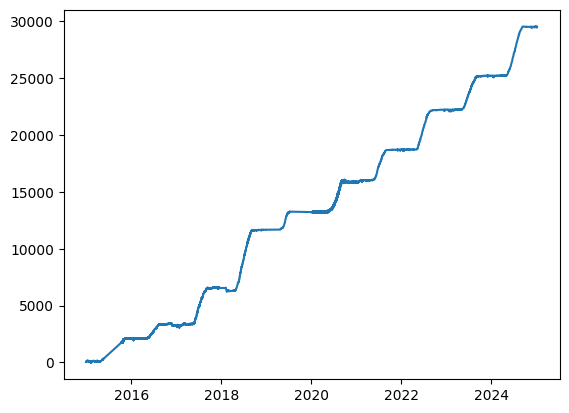

In [50]:
plt.plot(dendro18l2['ts'], dendro18l2['value'])

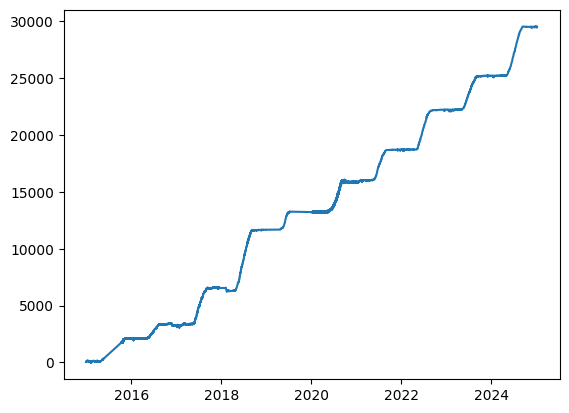

In [53]:
plt.plot(dendro18lm['ts'], dendro18lm['value'])

In [ ]:
DM = pd.read_feather('/storage/lukovic/Data/FORWARDS/treenet/server_data/dendrometer_lm/dendrometer_lm_hourly_series_id_18.ftr')[['ts','value']]
DM

KeyError: "['values'] not in index"